# CNN Predict — Event Dependence by Climate-Index Phase

Analyses the relationship between ENSO / IPO / Arctic SST phase and the
probability of (1) CNN-predicted true-positive slowdowns and (2) all
slowdowns.  Statistics include chi-squared / Fisher exact tests, bootstrap
confidence intervals, variance explained by phase, and logistic regression
odds ratios.

**Prerequisites**
- `scripts/03_cesm2le_tvt_splits.py` — TVT splits **and** `--climate-indices-only`
- `scripts/04_cesm2le_cnn_train.py` — train CNN models
- `scripts/06_cnn_predict_cesm2le.py` — precompute and save predictions

**Set `N_SPLITS` and `N_SEEDS` to match the values used during training, then Run All.**

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency, fisher_exact, norm

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.splits import load_tvt_split
from src.cnn.model  import METRIC_NAMES

# Standardize figure appearance for publication
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

2026-04-16 12:04:33.138823: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 12:04:33.141427: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-16 12:04:33.190430: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 12:04:33.190472: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 12:04:33.190509: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Config

In [2]:
# How many splits / seeds were trained
N_SPLITS  = 9          # max 9
N_SEEDS   = 5          # random seeds per split
BASE_SEED = 42

# Dataset
BLOCK_SIZE = 10        # ensemble members per TVT block
START_YEAR = 1990      # first year in the loaded splits

METRICS_DIR     = paths.RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = paths.RESULTS_DIR / 'predictions' / 'cesm2le'

## Load loop
Loads TVT splits (for labels) and **precomputed CNN predictions**.
LRP is **not** loaded here (not needed for event-dependence analysis).

> **Note:** Model inference is no longer performed here. Predictions are loaded from
> files produced by `scripts/06_cnn_predict_cesm2le.py`.

In [3]:
results = {}

for split_idx in range(N_SPLITS):
    print(f'\n{chr(9472)*60}')
    print(f'Split {split_idx}')
    print(f'{chr(9472)*60}')

    # TVT split (for labels only — no SST arrays needed here)
    split_path = paths.tvt_split_path(split_idx)
    if not split_path.exists():
        raise FileNotFoundError(
            f'TVT split not found: {split_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py first.'
        )
    split = load_tvt_split(split_path)

    y_tr = split['slow_tr']
    y_va = split['slow_va']
    y_te = split['slow_te']
    y_true = {'train': y_tr, 'val': y_va, 'test': y_te}

    print(f'  Train: ({len(y_tr)},)  prevalence={y_tr.mean():.3f}')
    print(f'  Val  : ({len(y_va)},)  prevalence={y_va.mean():.3f}')
    print(f'  Test : ({len(y_te)},)  prevalence={y_te.mean():.3f}')

    y_scores_runs = []

    for run_idx in range(N_SEEDS):
        print(f'  seed {BASE_SEED + run_idx}: ', end='', flush=True)

        # Load precomputed predictions
        pred_path = PREDICTIONS_DIR / f'cnn_prediction_cesm2le_M{split_idx}_{run_idx}.nc'
        if not pred_path.exists():
            raise FileNotFoundError(
                f'Prediction file not found: {pred_path}\n'
                f'Run scripts/06_cnn_predict_cesm2le.py first.'
            )
        with xr.open_dataset(pred_path) as ds_pred:
            y_scores_runs.append({
                'train': ds_pred['y_prob_train'].values,
                'val':   ds_pred['y_prob_val'].values,
                'test':  ds_pred['y_prob_test'].values,
            })
        print('predictions \u2713')

    results[split_idx] = {
        'y_scores_runs': y_scores_runs,
        'y_true':        y_true,
        'n_tr':          len(y_tr),
    }

print('\nLoading complete.')


────────────────────────────────────────────────────────────
Split 0
────────────────────────────────────────────────────────────
  Train: (4080,)  prevalence=0.275
  Val  : (510,)  prevalence=0.310
  Test : (510,)  prevalence=0.267
  seed 42: predictions ✓
  seed 43: predictions ✓
  seed 44: predictions ✓
  seed 45: predictions ✓
  seed 46: predictions ✓

────────────────────────────────────────────────────────────
Split 1
────────────────────────────────────────────────────────────
  Train: (4080,)  prevalence=0.271
  Val  : (510,)  prevalence=0.300
  Test : (510,)  prevalence=0.310
  seed 42: predictions ✓
  seed 43: predictions ✓
  seed 44: predictions ✓
  seed 45: predictions ✓
  seed 46: predictions ✓

────────────────────────────────────────────────────────────
Split 2
────────────────────────────────────────────────────────────
  Train: (4080,)  prevalence=0.274
  Val  : (510,)  prevalence=0.286
  Test : (510,)  prevalence=0.300
  seed 42: predictions ✓
  seed 43: predictions 

## Load climate indices

In [4]:
# Load split-aligned climate indices
for split_idx in range(N_SPLITS):
    idx_path = paths.TVT_SPLITS_DIR / f'cesm2le_climate_indices_split{split_idx}.nc'
    if not idx_path.exists():
        raise FileNotFoundError(
            f'Climate index split not found: {idx_path}\n'
            f'Run scripts/03_cesm2le_tvt_splits.py --climate-indices-only first.'
        )
    with xr.open_dataset(idx_path) as ds_idx:
        for vname in ds_idx.data_vars:
            results[split_idx][vname] = ds_idx[vname].values
print('Climate indices loaded for all splits.')

# Phase definitions
# ENSO: +/-0.4 std (3 phases)
ENSO_PHASES  = (-1, 0, 1)
ENSO_LABELS  = ('La Ni\u00f1a', 'Neutral', 'El Ni\u00f1o')

def enso_phase_labels(idx_vals):
    'Assign ENSO phase labels: -1/0/+1 based on +/-0.4 threshold.'
    out = np.zeros(len(idx_vals), dtype=int)
    out[idx_vals <= -0.4] = -1
    out[idx_vals >=  0.4] =  1
    return out

# IPO: sign-based (2 phases)
IPO_PHASES  = (-1, 1)
IPO_LABELS  = ('\u2212', '+')

def ipo_phase_labels(idx_vals):
    'Assign IPO phase labels: -1/+1 based on sign.'
    return np.where(idx_vals <= 0, -1, 1).astype(int)

# Arctic SST: +/-1.0 std (3 phases)
ARCTIC_PHASES  = (-1, 0, 1)
ARCTIC_LABELS  = ('\u2212', 'Neutral', '+')

def arctic_phase_labels(idx_vals):
    'Assign Arctic SST phase labels: -1/0/+1 based on +/-1.0 threshold.'
    out = np.zeros(len(idx_vals), dtype=int)
    out[idx_vals <= -1.0] = -1
    out[idx_vals >=  1.0] =  1
    return out

Climate indices loaded for all splits.


## Statistical helper functions

In [5]:
def event_dependence_by_phase(phase_labels, event_bool, phases=(-1, 0, 1), B=5000):
    'P(event | phase) with chi2/Fisher test and bootstrap CIs.'
    phase_labels = np.asarray(phase_labels)
    event_bool   = np.asarray(event_bool, dtype=bool)

    probs, counts, n_phase, ci_lo, ci_hi = {}, {}, {}, {}, {}

    for ph in phases:
        sel = phase_labels == ph
        n   = sel.sum()
        n_phase[ph] = int(n)
        k = event_bool[sel].sum()
        counts[ph] = int(k)
        probs[ph]  = k / n if n > 0 else np.nan

        rng   = np.random.default_rng(42)
        boots = np.empty(B)
        sub   = event_bool[sel].astype(float)
        for b in range(B):
            boots[b] = rng.choice(sub, size=n, replace=True).mean()
        ci_lo[ph], ci_hi[ph] = np.percentile(boots, [2.5, 97.5])

    table = np.array([[counts.get(ph, 0), n_phase.get(ph, 0) - counts.get(ph, 0)]
                       for ph in phases])
    if table.shape[0] >= 2 and table.min() >= 0:
        chi2_p = chi2_contingency(table)[1]
        fisher_p = fisher_exact(table)[1] if table.shape[0] == 2 else np.nan
    else:
        chi2_p = fisher_p = np.nan

    return dict(probs=probs, counts=counts, n_phase=n_phase,
                ci_lo=ci_lo, ci_hi=ci_hi, chi2_p=chi2_p, fisher_p=fisher_p)


def event_dependence_by_phase_multiseed(phase_labels, event_masks_seeds,
                                         phases=(-1, 0, 1), B=5000):
    'P(event | phase) with nested bootstrap over seeds and time.'
    phase_labels = np.asarray(phase_labels)
    n_seeds = len(event_masks_seeds)
    rng = np.random.default_rng(42)

    seed_probs = {ph: [] for ph in phases}
    for mask_s in event_masks_seeds:
        mask_s = np.asarray(mask_s, dtype=bool)
        for ph in phases:
            sel = phase_labels == ph
            n   = sel.sum()
            seed_probs[ph].append(mask_s[sel].mean() if n > 0 else np.nan)

    probs_mean = {ph: np.nanmean(seed_probs[ph]) for ph in phases}

    boot_probs = {ph: np.empty(B) for ph in phases}
    for b in range(B):
        seed_ids = rng.choice(n_seeds, size=n_seeds, replace=True)
        for ph in phases:
            sel = phase_labels == ph
            n = sel.sum()
            if n == 0:
                boot_probs[ph][b] = np.nan
                continue
            vals = []
            for si in seed_ids:
                sub = event_masks_seeds[si][sel].astype(float)
                vals.append(rng.choice(sub, size=n, replace=True).mean())
            boot_probs[ph][b] = np.nanmean(vals)

    ci_lo = {ph: np.nanpercentile(boot_probs[ph], 2.5)  for ph in phases}
    ci_hi = {ph: np.nanpercentile(boot_probs[ph], 97.5) for ph in phases}

    table = []
    for ph in phases:
        n = (phase_labels == ph).sum()
        k = int(round(probs_mean[ph] * n))
        table.append([k, n - k])
    table = np.array(table)
    chi2_p = chi2_contingency(table)[1] if table.shape[0] >= 2 else np.nan

    return dict(probs_mean=probs_mean, ci_lo=ci_lo, ci_hi=ci_hi, chi2_p=chi2_p)


def variance_explained_by_phase(phase_labels, event_bool, phases=(-1, 0, 1), B=5000):
    'Between-phase variance / total variance of binary event, with bootstrap CI.'
    phase_labels = np.asarray(phase_labels)
    event_bool   = np.asarray(event_bool, dtype=float)
    grand_mean = event_bool.mean()
    total_var  = event_bool.var()
    if total_var == 0:
        return dict(ve=np.nan, ci_lo=np.nan, ci_hi=np.nan)

    between = 0.0
    for ph in phases:
        sel = phase_labels == ph
        n_ph = sel.sum()
        if n_ph == 0:
            continue
        between += n_ph * (event_bool[sel].mean() - grand_mean) ** 2
    between /= len(event_bool)
    ve = between / total_var

    rng = np.random.default_rng(42)
    boots = np.empty(B)
    n = len(event_bool)
    for b in range(B):
        idx = rng.choice(n, size=n, replace=True)
        eb = event_bool[idx]
        pl = phase_labels[idx]
        gm = eb.mean()
        tv = eb.var()
        if tv == 0:
            boots[b] = np.nan
            continue
        bw = 0.0
        for ph in phases:
            sel_b = pl == ph
            n_ph = sel_b.sum()
            if n_ph == 0:
                continue
            bw += n_ph * (eb[sel_b].mean() - gm) ** 2
        bw /= n
        boots[b] = bw / tv
    ci_lo, ci_hi = np.nanpercentile(boots, [2.5, 97.5])

    return dict(ve=ve, ci_lo=ci_lo, ci_hi=ci_hi)


def logit_or_r2(phase_labels, event_bool, phases=(-1, 0, 1)):
    'Logistic regression: odds ratio, McFadden R-squared, Wald CI.'
    X = phase_labels.reshape(-1, 1).astype(float)
    y = np.asarray(event_bool, dtype=int)

    if len(np.unique(y)) < 2:
        return dict(odds_ratio=np.nan, or_ci_lo=np.nan, or_ci_hi=np.nan, mcfadden_r2=np.nan)

    model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    model.fit(X, y)
    coef = model.coef_[0, 0]
    odds_ratio = np.exp(coef)

    # McFadden R-squared
    prob_pred = model.predict_proba(X)
    ll_model = np.sum(y * np.log(prob_pred[:, 1] + 1e-12) +
                      (1 - y) * np.log(prob_pred[:, 0] + 1e-12))
    p0 = y.mean()
    ll_null = np.sum(y * np.log(p0 + 1e-12) + (1 - y) * np.log(1 - p0 + 1e-12))
    mcfadden_r2 = 1 - ll_model / ll_null if ll_null != 0 else np.nan

    # Wald CI for odds ratio
    probs = prob_pred[:, 1]
    W = np.diag(probs * (1 - probs))
    try:
        Xd = np.hstack([np.ones((len(X), 1)), X])
        XtWX_inv = np.linalg.inv(Xd.T @ W @ Xd)
        se = np.sqrt(XtWX_inv[1, 1])
    except np.linalg.LinAlgError:
        se = np.nan
    or_ci_lo = np.exp(coef - 1.96 * se) if np.isfinite(se) else np.nan
    or_ci_hi = np.exp(coef + 1.96 * se) if np.isfinite(se) else np.nan

    return dict(odds_ratio=odds_ratio, or_ci_lo=or_ci_lo, or_ci_hi=or_ci_hi,
                mcfadden_r2=mcfadden_r2)

## Compute scenario masks

For each split and seed, compute TP / all-slowdown masks on **training** data.

In [6]:
for split_idx in range(N_SPLITS):
    res = results[split_idx]
    y_t = res['y_true']['train']

    tp_masks_seeds = []   # one per seed
    slow_mask      = (y_t == 1)   # all actual slowdowns

    for run_idx in range(N_SEEDS):
        y_s = res['y_scores_runs'][run_idx]['train']
        prec, rec, thr = precision_recall_curve(y_t, y_s)
        thr_best = thr[np.argmin(np.abs(prec[:-1] - rec[:-1]))] if thr.size > 0 else 0.5
        y_pred = (y_s >= thr_best).astype(int)
        tp_masks_seeds.append((y_pred == 1) & (y_t == 1))

    res['tp_masks_seeds'] = tp_masks_seeds
    res['slow_mask']      = slow_mask

print('Scenario masks computed for all splits and seeds.')

Scenario masks computed for all splits and seeds.


## Event-dependence plotting function

In [7]:
def plot_event_dependence(index_key_tr, index_name, phase_labeler,
                         phases, phase_names, figsize=(15, 5)):
    '''Event dependence analysis for one climate index.'''
    n_phases = len(phases)

    # Gather across all splits
    all_phase_labels = []
    all_slow_masks   = []
    all_tp_seeds     = []

    for si in range(N_SPLITS):
        res = results[si]
        idx_vals = res[index_key_tr]
        plabels  = phase_labeler(idx_vals)

        all_phase_labels.append(plabels)
        all_slow_masks.append(res['slow_mask'])
        all_tp_seeds.append(res['tp_masks_seeds'])

    # Concatenate across splits
    phase_cat = np.concatenate(all_phase_labels)
    slow_cat  = np.concatenate(all_slow_masks)

    # TP: concatenate per-seed across splits
    tp_cat_seeds = []
    for seed_idx in range(N_SEEDS):
        tp_cat_seeds.append(np.concatenate([
            all_tp_seeds[si][seed_idx] for si in range(N_SPLITS)
        ]))

    # Statistics
    res_slow = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_tp = event_dependence_by_phase_multiseed(
        phase_cat, tp_cat_seeds, phases=phases, B=5000
    )
    ve_slow = variance_explained_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    tp_avg = np.mean(np.stack(tp_cat_seeds, axis=0), axis=0) >= 0.5
    ve_tp = variance_explained_by_phase(phase_cat, tp_avg, phases=phases, B=5000)
    lr_slow = logit_or_r2(phase_cat, slow_cat, phases=phases)
    lr_tp = logit_or_r2(phase_cat, tp_avg, phases=phases)

    # Summary text builder
    def _stats_text(rd, ved, lrd, label):
        lines = [f'{label}:']
        if 'chi2_p' in rd:
            lines.append(f'  chi2 p = {rd["chi2_p"]:.4f}')
        fp = rd.get('fisher_p', np.nan)
        if np.isfinite(fp):
            lines.append(f'  Fisher p = {fp:.4f}')
        lines.append(f'  VE = {ved["ve"]:.3f} [{ved["ci_lo"]:.3f}, {ved["ci_hi"]:.3f}]')
        lines.append(f'  OR = {lrd["odds_ratio"]:.3f} [{lrd["or_ci_lo"]:.3f}, {lrd["or_ci_hi"]:.3f}]')
        lines.append(f'  McFadden R2 = {lrd["mcfadden_r2"]:.4f}')
        return '\n'.join(lines)

    slow_text = _stats_text(res_slow, ve_slow, lr_slow, 'All slowdowns')
    tp_text   = _stats_text(res_tp,   ve_tp,   lr_tp,   'TP slowdowns')

    # ------------------------------------------------------------------
    # Figure: (a) conditional probability bars, (b) composition table
    # ------------------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize,
                                   gridspec_kw={'width_ratios': [1.1, 1]})

    x = np.arange(n_phases)
    width = 0.35

    slow_probs = [res_slow['probs'][ph] for ph in phases]
    slow_lo    = [res_slow['probs'][ph] - res_slow['ci_lo'][ph] for ph in phases]
    slow_hi    = [res_slow['ci_hi'][ph] - res_slow['probs'][ph] for ph in phases]

    tp_probs   = [res_tp['probs_mean'][ph] for ph in phases]
    tp_lo      = [res_tp['probs_mean'][ph] - res_tp['ci_lo'][ph] for ph in phases]
    tp_hi      = [res_tp['ci_hi'][ph] - res_tp['probs_mean'][ph] for ph in phases]

    ax1.bar(x - width / 2, slow_probs, width, yerr=[slow_lo, slow_hi],
            color='gray', alpha=0.6, edgecolor='black', capsize=3, label='All slowdowns')
    ax1.bar(x + width / 2, tp_probs, width, yerr=[tp_lo, tp_hi],
            color='steelblue', alpha=0.7, edgecolor='black', capsize=3, label='TP slowdowns')
    ax1.set_xticks(x)
    ax1.set_xticklabels(phase_names)
    ax1.set_ylabel('P(event | phase)')
    ax1.set_title('(a)')
    ax1.legend()
    ax1.set_ylim(0, min(1.0, max(slow_probs + tp_probs) * 1.5 + 0.05))

    # Panel (b): composition TABLE
    ax2.axis('off')
    col_labels = ['n', '#slow', '#TP', 'P(slow)', 'P(TP)']
    rows = []
    for ph in phases:
        in_phase = (phase_cat == ph)
        n_ph   = int(in_phase.sum())
        n_slow = int(slow_cat[in_phase].sum())
        p_slow = res_slow['probs'][ph]
        p_tp   = res_tp['probs_mean'][ph]
        n_tp = int(round(np.mean([
            int(tp_seed[in_phase].sum()) for tp_seed in tp_cat_seeds
        ])))
        rows.append([
            f'{n_ph:d}', f'{n_slow:d}', f'{n_tp:d}',
            f'{p_slow:.3f}', f'{p_tp:.3f}',
        ])

    tbl = ax2.table(
        cellText=rows,
        rowLabels=list(phase_names),
        colLabels=col_labels,
        cellLoc='center',
        rowLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 1.6)

    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e8eef5')
        elif c == -1:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f3f3f3')

    ax2.set_title('(b)')

    combined_text = slow_text + '\n\n' + tp_text
    fig.text(0.99, 0.02, combined_text, fontsize=7, va='bottom', ha='right',
             family='monospace',
             bbox=dict(boxstyle='round,pad=0.4', fc='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'\n{"="*60}')
    print(f'{index_name} Summary')
    print(f'{"="*60}')
    print(combined_text)
    print(f'{"="*60}\n')

---
## Event dependence by climate-index phase

Each call produces an overlay bar chart (gray = all slowdowns, blue = TP slowdowns)
with bootstrap CIs, sample counts, and a statistics summary including chi-squared,
Fisher exact, variance explained, and logistic regression odds ratio.

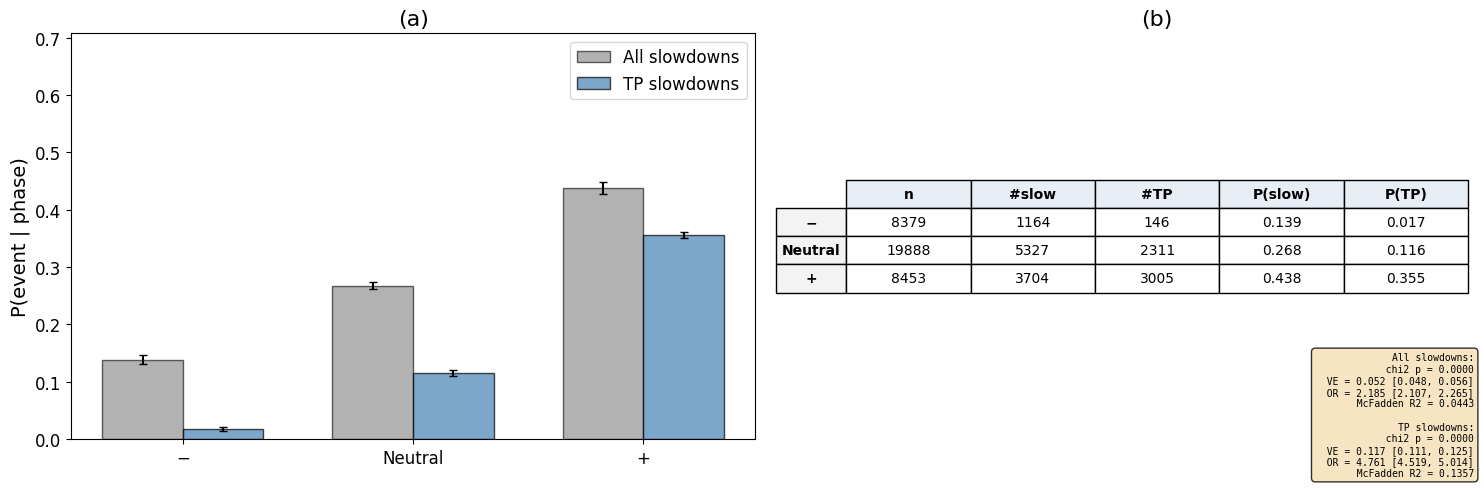


Arctic SST Summary
All slowdowns:
  chi2 p = 0.0000
  VE = 0.052 [0.048, 0.056]
  OR = 2.185 [2.107, 2.265]
  McFadden R2 = 0.0443

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.117 [0.111, 0.125]
  OR = 4.761 [4.519, 5.014]
  McFadden R2 = 0.1357



In [8]:
plot_event_dependence(
    index_key_tr  = 'arctic_tr',
    index_name    = 'Arctic SST',
    phase_labeler = arctic_phase_labels,
    phases        = ARCTIC_PHASES,
    phase_names   = ARCTIC_LABELS,
)

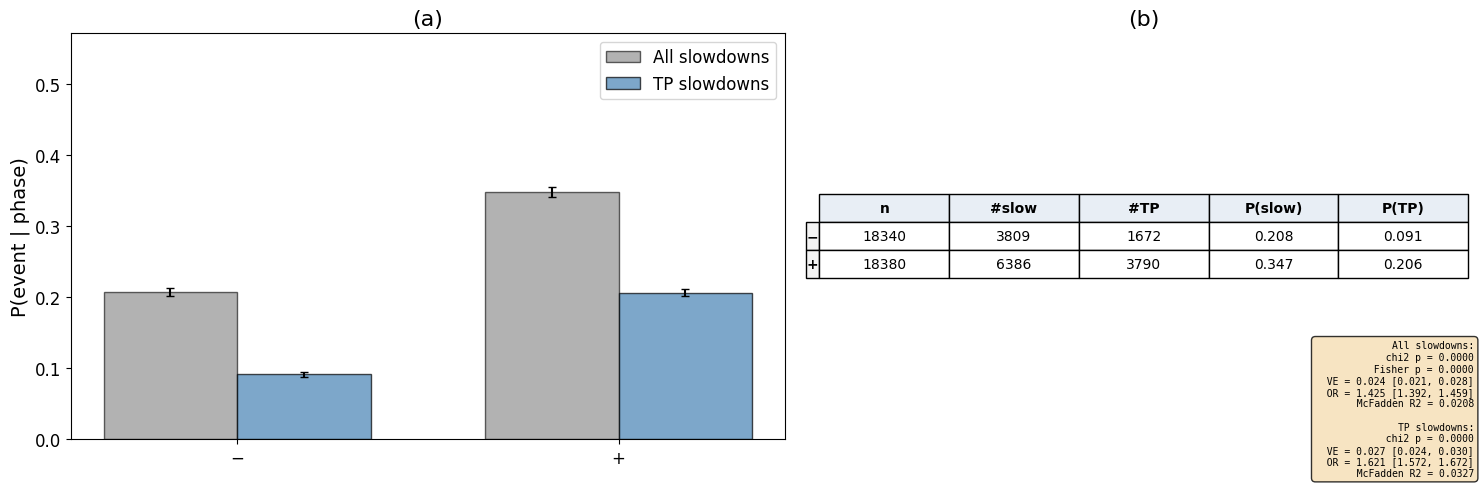


IPO Summary
All slowdowns:
  chi2 p = 0.0000
  Fisher p = 0.0000
  VE = 0.024 [0.021, 0.028]
  OR = 1.425 [1.392, 1.459]
  McFadden R2 = 0.0208

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.027 [0.024, 0.030]
  OR = 1.621 [1.572, 1.672]
  McFadden R2 = 0.0327



In [9]:
plot_event_dependence(
    index_key_tr  = 'ipo_tr',
    index_name    = 'IPO',
    phase_labeler = ipo_phase_labels,
    phases        = IPO_PHASES,
    phase_names   = IPO_LABELS,
)

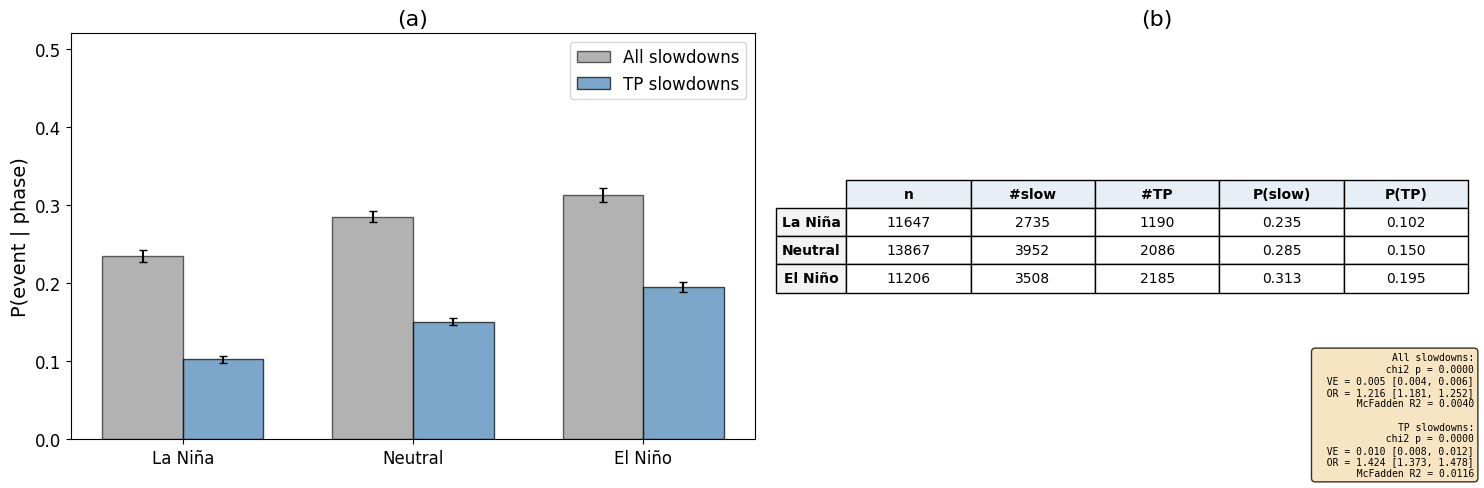


Nino3.4 (ENSO) Summary
All slowdowns:
  chi2 p = 0.0000
  VE = 0.005 [0.004, 0.006]
  OR = 1.216 [1.181, 1.252]
  McFadden R2 = 0.0040

TP slowdowns:
  chi2 p = 0.0000
  VE = 0.010 [0.008, 0.012]
  OR = 1.424 [1.373, 1.478]
  McFadden R2 = 0.0116



In [10]:
plot_event_dependence(
    index_key_tr  = 'nino34_tr',
    index_name    = 'Nino3.4 (ENSO)',
    phase_labeler = enso_phase_labels,
    phases        = ENSO_PHASES,
    phase_names   = ENSO_LABELS,
)

---
## Combined summary figure

Single figure with 3 subpanels (one per index) showing P(event | phase)
for both all slowdowns and TP slowdowns.

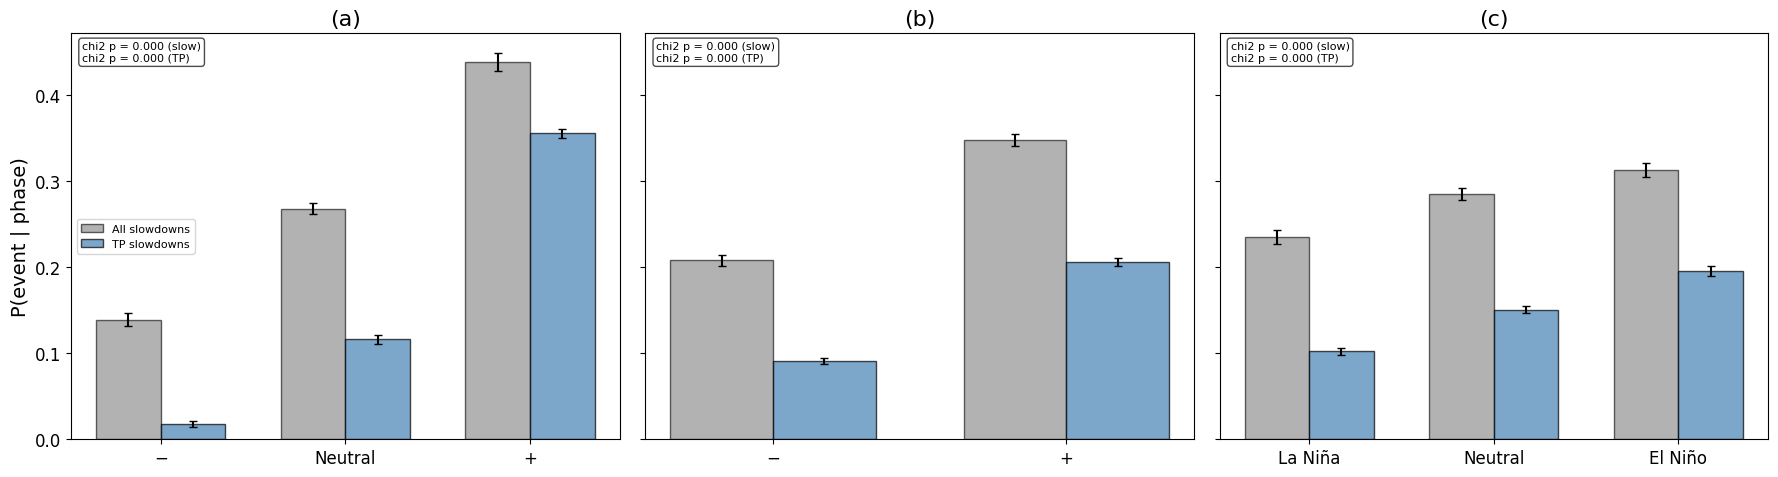

In [11]:
INDEX_CONFIGS = [
    ('arctic_tr', 'Arctic SST', arctic_phase_labels, ARCTIC_PHASES, ARCTIC_LABELS),
    ('ipo_tr',    'IPO',        ipo_phase_labels,    IPO_PHASES,    IPO_LABELS),
    ('nino34_tr', 'Nino3.4',    enso_phase_labels,   ENSO_PHASES,   ENSO_LABELS),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

panel_labels = ['(a)', '(b)', '(c)']

for ax, (key, name, labeler, phases, pnames), plabel in zip(axes, INDEX_CONFIGS, panel_labels):
    # Pool across splits
    phase_cat = np.concatenate([labeler(results[si][key]) for si in range(N_SPLITS)])
    slow_cat  = np.concatenate([results[si]['slow_mask'] for si in range(N_SPLITS)])
    tp_seeds  = [np.concatenate([results[si]['tp_masks_seeds'][ri]
                                  for si in range(N_SPLITS)])
                 for ri in range(N_SEEDS)]

    res_s = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_t = event_dependence_by_phase_multiseed(phase_cat, tp_seeds, phases=phases, B=5000)

    n_ph = len(phases)
    x = np.arange(n_ph)
    w = 0.35

    sp = [res_s['probs'][ph] for ph in phases]
    s_lo = [res_s['probs'][ph] - res_s['ci_lo'][ph] for ph in phases]
    s_hi = [res_s['ci_hi'][ph] - res_s['probs'][ph] for ph in phases]

    tp = [res_t['probs_mean'][ph] for ph in phases]
    t_lo = [res_t['probs_mean'][ph] - res_t['ci_lo'][ph] for ph in phases]
    t_hi = [res_t['ci_hi'][ph] - res_t['probs_mean'][ph] for ph in phases]

    ax.bar(x - w/2, sp, w, yerr=[s_lo, s_hi], color='gray', alpha=0.6,
           edgecolor='black', capsize=3, label='All slowdowns')
    ax.bar(x + w/2, tp, w, yerr=[t_lo, t_hi], color='steelblue', alpha=0.7,
           edgecolor='black', capsize=3, label='TP slowdowns')

    ax.set_xticks(x)
    ax.set_xticklabels(pnames)
    ax.set_title(plabel)

    # Annotate chi2 p-value
    ax.text(0.02, 0.98, f'chi2 p = {res_s["chi2_p"]:.3f} (slow)\n'
                         f'chi2 p = {res_t["chi2_p"]:.3f} (TP)',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes[0].set_ylabel('P(event | phase)')
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

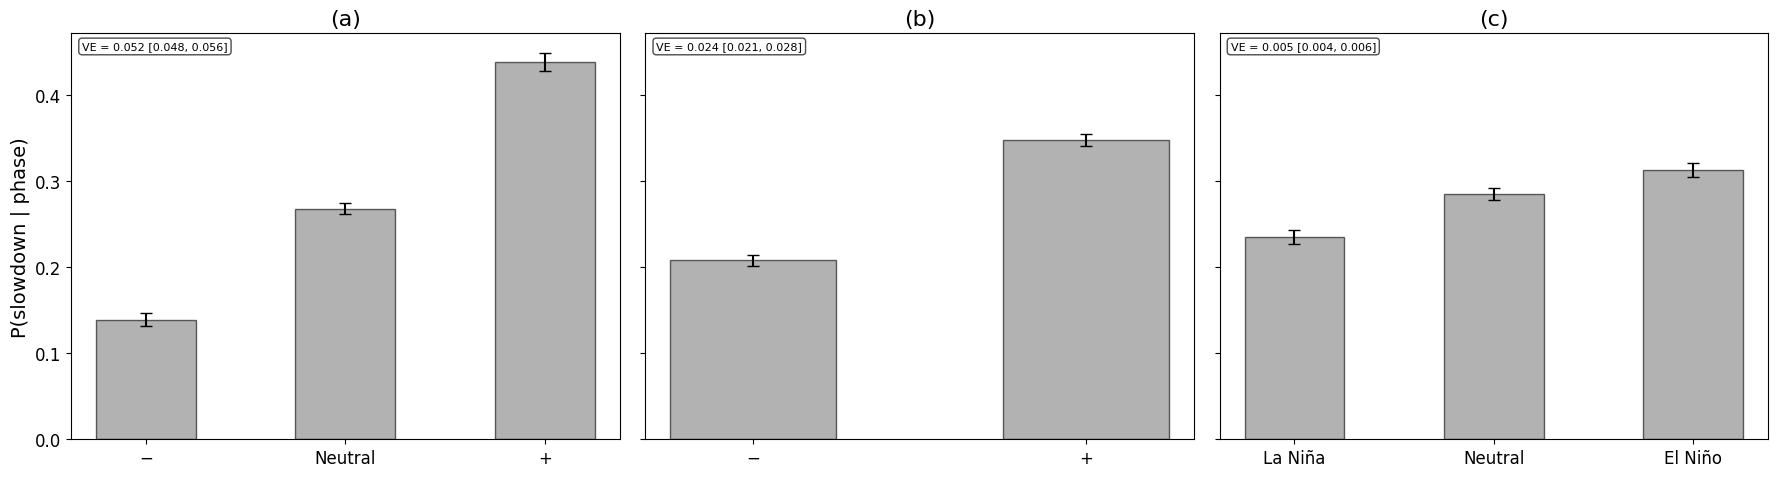

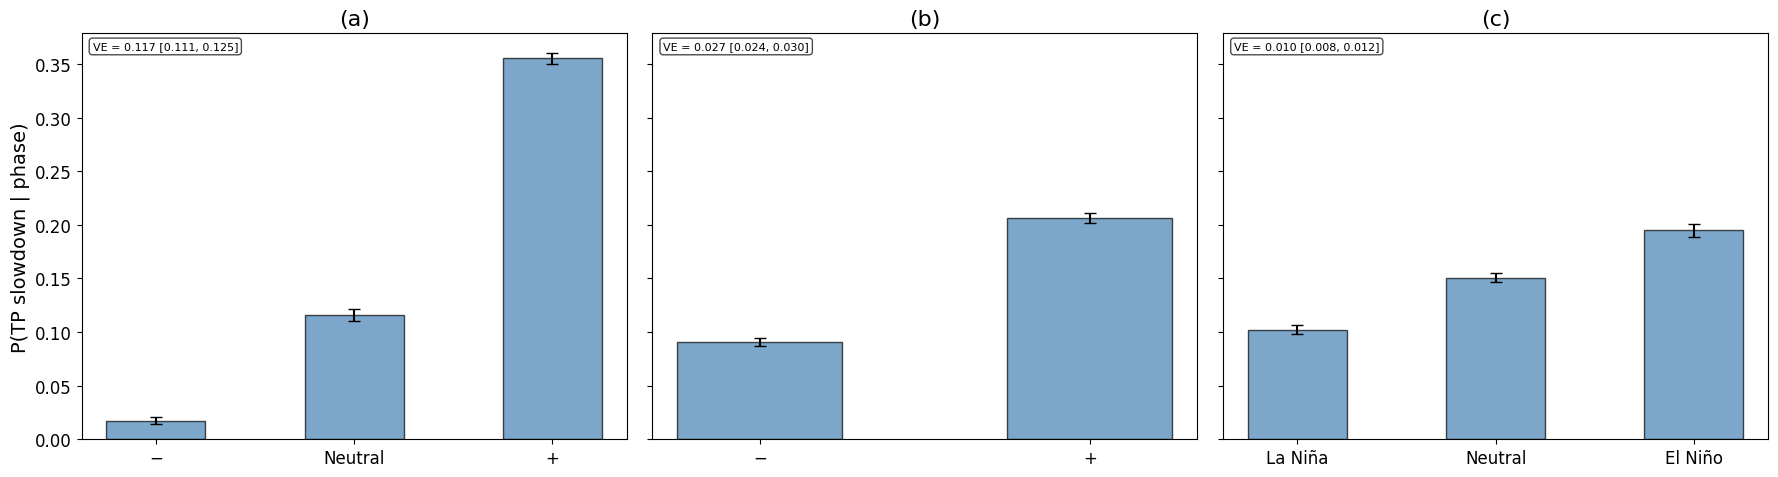

In [12]:
# Separate figures: (1) all slowdowns only, (2) TP slowdowns only
# Reuses INDEX_CONFIGS from the cell above.

# Pre-compute stats for all three indices
_cached = []
for key, name, labeler, phases, pnames in INDEX_CONFIGS:
    phase_cat = np.concatenate([labeler(results[si][key]) for si in range(N_SPLITS)])
    slow_cat  = np.concatenate([results[si]['slow_mask'] for si in range(N_SPLITS)])
    tp_seeds  = [np.concatenate([results[si]['tp_masks_seeds'][ri]
                                  for si in range(N_SPLITS)])
                 for ri in range(N_SEEDS)]

    res_s = event_dependence_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    res_t = event_dependence_by_phase_multiseed(phase_cat, tp_seeds, phases=phases, B=5000)

    ve_slow = variance_explained_by_phase(phase_cat, slow_cat, phases=phases, B=5000)
    tp_avg  = np.mean(np.stack(tp_seeds, axis=0), axis=0) >= 0.5
    ve_tp   = variance_explained_by_phase(phase_cat, tp_avg, phases=phases, B=5000)

    _cached.append(dict(
        name=name, phases=phases, pnames=pnames,
        res_s=res_s, res_t=res_t, ve_slow=ve_slow, ve_tp=ve_tp,
    ))

panel_labels = ['(a)', '(b)', '(c)']

# --- Figure 1: All slowdowns (grey bars) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, d, plabel in zip(axes1, _cached, panel_labels):
    phases = d['phases']
    n_ph = len(phases)
    x = np.arange(n_ph)

    sp   = [d['res_s']['probs'][ph]                       for ph in phases]
    s_lo = [d['res_s']['probs'][ph] - d['res_s']['ci_lo'][ph] for ph in phases]
    s_hi = [d['res_s']['ci_hi'][ph] - d['res_s']['probs'][ph] for ph in phases]

    ax.bar(x, sp, 0.5, yerr=[s_lo, s_hi], color='gray', alpha=0.6,
           edgecolor='black', capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(d['pnames'])
    ax.set_title(plabel)

    ve = d['ve_slow']
    ax.text(0.02, 0.98,
            f'VE = {ve["ve"]:.3f} [{ve["ci_lo"]:.3f}, {ve["ci_hi"]:.3f}]',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes1[0].set_ylabel('P(slowdown | phase)')
plt.tight_layout()
plt.show()

# --- Figure 2: TP slowdowns (blue bars) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, d, plabel in zip(axes2, _cached, panel_labels):
    phases = d['phases']
    n_ph = len(phases)
    x = np.arange(n_ph)

    tp   = [d['res_t']['probs_mean'][ph]                       for ph in phases]
    t_lo = [d['res_t']['probs_mean'][ph] - d['res_t']['ci_lo'][ph] for ph in phases]
    t_hi = [d['res_t']['ci_hi'][ph] - d['res_t']['probs_mean'][ph] for ph in phases]

    ax.bar(x, tp, 0.5, yerr=[t_lo, t_hi], color='steelblue', alpha=0.7,
           edgecolor='black', capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(d['pnames'])
    ax.set_title(plabel)

    ve = d['ve_tp']
    ax.text(0.02, 0.98,
            f'VE = {ve["ve"]:.3f} [{ve["ci_lo"]:.3f}, {ve["ci_hi"]:.3f}]',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes2[0].set_ylabel('P(TP slowdown | phase)')
plt.tight_layout()
plt.show()